# Predicting Failed Food Businesses: Modelling

**IAT 461, Summer 2026: Draft for the August 9 checkpoint**
Student: Mahdi Taziki (301373483)
Client: Jason Salonga, Greater Vancouver Food Bank

---

This notebook applies the decisions from [`01_EDA.ipynb`](01_EDA.ipynb) and
builds the first versions of the models. The modelling is not finished, so the
results should not be treated as final. The remaining work is listed in Section 9.

## 1. What this notebook does

1. Puts the cleaning decisions from the EDA into one function
2. Picks a label for the draft
3. Sets up the preprocessing and the two models
4. Compares them against two baselines with repeated cross-validation
5. Scores every business out of fold so I can look at the ranking
6. Looks at which features the models use
7. Lists what is left to do

## 2. How I am measuring results

The plan is to give the food bank a ranked list, so accuracy is not a useful
measure here. A model that predicts "not failed" for everyone gets 76.7% accuracy
on this data and never flags anybody.

I use **Average Precision (AP)**, which is what
`sklearn.metrics.average_precision_score` and the `average_precision` scorer
calculate. AP summarises the precision-recall curve. A ranking in random order
has an expected AP equal to the positive class rate, which is 0.233 here, so that
is the number to compare against.

I also look at **precision@k**, the share of the top k businesses in the ranking
that have a failure status, because that is closer to how a ranked list would
actually get used. ROC-AUC is reported as well since it is a familiar number, but
AP is the one I pay attention to because the positive class is small.

## 3. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, make_scorer,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder,
                                   StandardScaler)

SEED = 461
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = {"survived": "#4C78A8", "failed": "#E45756"}
MODEL_COLOURS = {
    "Logistic regression": "#5B8FF9",
    "Random forest": "#9A6FB0",
    "Majority baseline": "#8C8C8C",
    "Stratified random baseline": "#BFBFBF",
}
REFERENCE = "#767676"

SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
}

In [2]:
raw = pd.read_csv("../vancouver_food_businesses_sample.csv")
print(f"loaded {len(raw)} rows")

loaded 221 rows


## 4. Cleaning

These are the decisions I made in `01_EDA.ipynb`. I put them in one function so
the modelling table can be rebuilt in a single step.

| Step | Why, from the EDA |
|---|---|
| Keep the latest record per `licencenumber` | Two licences appear twice with different statuses |
| Business types with fewer than 5 records become `Other` | `Food Market` only has one record |
| Neighbourhoods with fewer than 8 records become `Other areas` | 8 of the 20 neighbourhoods are small and would add columns without much data behind them |
| Drop `issueddate`, `expireddate`, `feepaid`, `folderyear`, `postalcode` | Leakage, nearly constant, or mostly missing |

`issueddate` is used to sort before dropping duplicates so the row that survives
is the most recent one. It is not passed to the models.

The two grouping thresholds (5 and 8) were chosen while looking at the whole
dataset during the EDA, and they are applied here as
fixed cleaning rules before any splitting. They are not refitted inside each
cross-validation fold. That means the category groupings have seen all of the
data. I do not think this is a large effect since the thresholds only depend on
category counts and not on the label, but it is a limitation of the setup.

In [3]:
NARROW_STATUSES = ["Cancelled", "Gone Out of Business"]
WIDE_STATUSES = NARROW_STATUSES + ["Pending", "Inactive"]

MIN_TYPE_N = 5
MIN_AREA_N = 8

CAT_FEATURES = ["businesstype_grouped", "localarea_grouped"]
NUM_FEATURES = ["numberofemployees"]
FEATURES = CAT_FEATURES + NUM_FEATURES


def prepare(frame):
    out = frame.copy()

    out["failed_narrow"] = out["status"].isin(NARROW_STATUSES).astype(int)
    out["failed_wide"] = out["status"].isin(WIDE_STATUSES).astype(int)

    out = (out.sort_values("issueddate")
              .drop_duplicates("licencenumber", keep="last")
              .reset_index(drop=True))

    type_counts = out["businesstype"].value_counts()
    rare_types = type_counts[type_counts < MIN_TYPE_N].index
    out["businesstype_grouped"] = out["businesstype"].where(
        ~out["businesstype"].isin(rare_types), "Other")

    area_counts = out["localarea"].value_counts()
    kept_areas = area_counts[area_counts >= MIN_AREA_N].index
    out["localarea_grouped"] = out["localarea"].where(
        out["localarea"].isin(kept_areas), "Other areas")

    return out


model_df = prepare(raw)

print(f"rows           : {len(raw)} -> {len(model_df)} after dropping duplicates")
print(f"business types : {raw['businesstype'].nunique()} -> "
      f"{model_df['businesstype_grouped'].nunique()} after grouping")
print(f"neighbourhoods : {raw['localarea'].nunique()} -> "
      f"{model_df['localarea_grouped'].nunique()} after grouping")
print(f"missing values in the predictors: "
      f"{int(model_df[FEATURES].isna().sum().sum())}")

model_df[FEATURES + ["status", "failed_narrow", "failed_wide"]].head()

rows           : 221 -> 219 after dropping duplicates
business types : 6 -> 6 after grouping
neighbourhoods : 20 -> 13 after grouping
missing values in the predictors: 0


,businesstype_grouped,localarea_grouped,numberofemployees,status,failed_narrow,failed_wide
0,Wholesale Dealer - Food,Strathcona,30.0,Issued,0,0
1,Wholesale Dealer - Food,Marpole,2.0,Issued,0,0
2,Wholesale Dealer - Food,Strathcona,8.0,Issued,0,0
3,Retail Dealer - Food,Hastings-Sunrise,89.0,Issued,0,0
4,Wholesale Dealer - Food,Hastings-Sunrise,89.0,Issued,0,0


### 4.1 Which label I used for the draft

Because the EDA left the label question open, I used the **wide label** for this draft
(`Cancelled`, `Gone Out of Business`, `Pending`, `Inactive`). It is the definition
written in the Phase 2 agreement, and it has 51 positives, while the narrow label
has 20, which is about 4 per fold in 5-fold cross-validation. That is very few to
compare models with.

Using the wide label here is a practical choice for the draft and not an answer to
the question. Whether a `Pending` licence should count as a failed business still
needs to be confirmed with the client, and Section 9 keeps the sensitivity check
on the list of things to do.

In [4]:
labels = pd.DataFrame({
    "positives": [model_df["failed_narrow"].sum(), model_df["failed_wide"].sum()],
    "rate": [model_df["failed_narrow"].mean(), model_df["failed_wide"].mean()],
    "positives per fold (5-fold)": [
        round(model_df["failed_narrow"].sum() / 5, 1),
        round(model_df["failed_wide"].sum() / 5, 1)],
}, index=["narrow", "wide"]).round(3)

LABEL = "failed_wide"
X = model_df[FEATURES]
y = model_df[LABEL]
PREVALENCE = y.mean()

print(f"draft target      : {LABEL}")
print(f"positives         : {y.sum()} of {len(y)}")
print(f"positive rate     : {PREVALENCE:.1%}  (expected AP of a random ranking)")
print(f"majority accuracy : {1 - PREVALENCE:.1%}  (why I am not using accuracy)\n")
labels

draft target      : failed_wide
positives         : 51 of 219
positive rate     : 23.3%  (expected AP of a random ranking)
majority accuracy : 76.7%  (why I am not using accuracy)



,positives,rate,positives per fold (5-fold)
narrow,20,0.091,4.0
wide,51,0.233,10.2


## 5. Preprocessing and models

The encoder and the scaler sit inside a `Pipeline` so they are fitted on the
training part of each fold only. As noted in Section 4, the category grouping is
not part of this; it is applied earlier as a fixed cleaning rule.

The two models get different numeric handling:

- **Logistic regression**: `log1p` on `numberofemployees` and then
  `StandardScaler`. The EDA found this column very right skewed, with a median of
  5 and a maximum of 1,955.
- **Random forest**: the raw employee count, passed straight through. Trees split
  on the order of the values, so scaling or a log transform would not change the
  splits.

Both classifiers use balanced class weights because only 23.3% of the rows are
positive. I have not compared this against unweighted versions, so I am only
saying it is the setting I chose, not that it is better.

In [5]:
logistic_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ("num", Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ]), NUM_FEATURES),
])

forest_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ("num", "passthrough", NUM_FEATURES),
])

MODELS = {
    "Majority baseline": Pipeline([
        ("pre", forest_preprocessor),
        ("clf", DummyClassifier(strategy="most_frequent"))]),
    "Stratified random baseline": Pipeline([
        ("pre", forest_preprocessor),
        ("clf", DummyClassifier(strategy="stratified", random_state=SEED))]),
    "Logistic regression": Pipeline([
        ("pre", logistic_preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                                   random_state=SEED))]),
    "Random forest": Pipeline([
        ("pre", forest_preprocessor),
        ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                       class_weight="balanced_subsample",
                                       random_state=SEED, n_jobs=-1))]),
}

n_encoded = clone(forest_preprocessor).fit_transform(X).shape[1]
print(f"predictors             : {len(FEATURES)}")
print(f"columns after encoding : {n_encoded}")
print(f"rows per column        : {len(X) / n_encoded:.1f}")

predictors             : 3
columns after encoding : 20
rows per column        : 10.9


There are 219 rows, 20 encoded columns and 51 positives, so this is a small
dataset for a model with this many columns. That is part of why I kept the forest
simple with `min_samples_leaf=3` rather than letting it grow all the way out.

### 5.1 Cross-validation

A single 80/20 split would put about 10 positives in the test set, and the score
would move a lot depending on which ones landed there. So I used **5-fold
stratified cross-validation repeated 10 times**, which gives 50 fold scores per
model, and I report the standard deviation across those folds as well as the mean.

The **majority baseline** never predicts a positive and shows what accuracy alone
would look like. The
**stratified random baseline** guesses at the base rate. Neither of them is a
strong competitor, and neither is the same thing as the theoretical AP of a
random ranking, which is just the positive class rate of 0.233.

In [6]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

rows = []
for name, model in MODELS.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=SCORING,
                            n_jobs=-1, error_score=np.nan)
    rows.append({
        "model": name,
        "AP": np.nanmean(scores["test_average_precision"]),
        "AP sd": np.nanstd(scores["test_average_precision"]),
        "ROC-AUC": np.nanmean(scores["test_roc_auc"]),
        "recall": np.nanmean(scores["test_recall"]),
        "precision": np.nanmean(scores["test_precision"]),
    })

cv_results = pd.DataFrame(rows).set_index("model").round(3)
print(f"a random ranking has an expected AP of {PREVALENCE:.3f}\n")
cv_results

a random ranking has an expected AP of 0.233



,AP,AP sd,ROC-AUC,recall,precision
model,,,,,
Majority baseline,0.233,0.009,0.500,0.000,0.000
Stratified random baseline,0.257,0.021,0.546,0.272,0.314
Logistic regression,0.375,0.066,0.641,0.602,0.298
Random forest,0.385,0.084,0.648,0.461,0.315


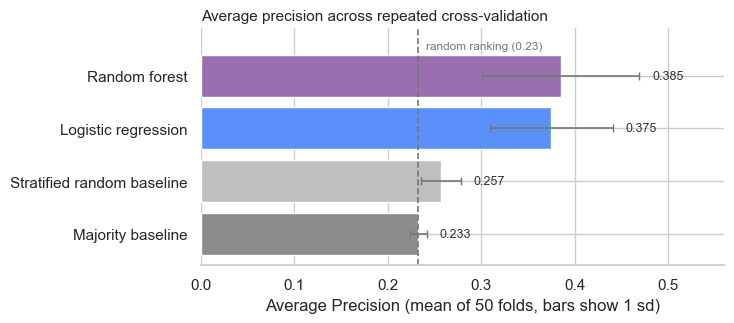

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))

order = cv_results.sort_values("AP").index
values = cv_results.loc[order, "AP"]
errors = cv_results.loc[order, "AP sd"]

bars = ax.barh(order, values, xerr=errors,
               color=[MODEL_COLOURS[m] for m in order],
               error_kw={"ecolor": REFERENCE, "elinewidth": 1.2, "capsize": 3})
for bar, value, error in zip(bars, values, errors):
    ax.text(value + error + 0.014, bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}", va="center", fontsize=9, color="#333333")

ax.axvline(PREVALENCE, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.set_ylim(-0.6, len(order) - 0.1)
ax.text(PREVALENCE + 0.008, len(order) - 0.35,
        f"random ranking ({PREVALENCE:.2f})", fontsize=8.5, color=REFERENCE,
        va="top")

ax.set_xlabel("Average Precision (mean of 50 folds, bars show 1 sd)")
ax.set_title("Average precision across repeated cross-validation", loc="left",
             fontsize=11)
ax.set_xlim(0, 0.56)
sns.despine(left=True)
fig.tight_layout()
fig.savefig("../figures/08_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Model comparison results

Logistic regression averaged an AP of 0.375 and the random forest 0.385, against
0.233 for a random ranking. Both are above the random ranking value, so the
predictors carry some signal.

The two averages are close, and this analysis does not show that either model is
better than the other. The standard deviations, 0.066 and 0.084, describe how much
each model's score moves from fold to fold. They are not a test of whether the
models differ, and I have not run one.

ROC-AUC is 0.641 for logistic regression and 0.648 for the forest, against 0.500
for the majority baseline and 0.546 for the stratified random baseline.

The majority baseline gets 0 recall and 0 precision because it never predicts a
failure, even though its accuracy would be 76.7%. This shows why accuracy alone
is not useful for this project.

## 6. Looking at the ranking

To see the ranking, I scored every business with `cross_val_predict` using one
5-fold split. Each business is scored by a model that did not train on it. This
gives one out-of-fold ranking of all 219 businesses.

Because this uses a single split, the results in this section are less stable than
the repeated cross-validation above, and I would not read too much into small
differences.

In [8]:
oof_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
RANKING_MODELS = ["Logistic regression", "Random forest"]

oof_scores = {}
for name in RANKING_MODELS:
    oof_scores[name] = cross_val_predict(
        MODELS[name], X, y, cv=oof_cv, method="predict_proba")[:, 1]

for name, scores in oof_scores.items():
    print(f"{name:20s} out-of-fold AP {average_precision_score(y, scores):.3f}  "
          f"ROC-AUC {roc_auc_score(y, scores):.3f}")

Logistic regression  out-of-fold AP 0.317  ROC-AUC 0.640
Random forest        out-of-fold AP 0.313  ROC-AUC 0.651


These AP values, 0.317 and 0.313, are lower than the 0.375 and 0.385 from Section
5 because Section 5 averages 50 fold scores, while this is one particular split
pooled into a single ranking. The difference gives some idea
of how much one split can move on this dataset. The repeated numbers are the ones
I would quote, but the single split is what produces a ranking I can look at.

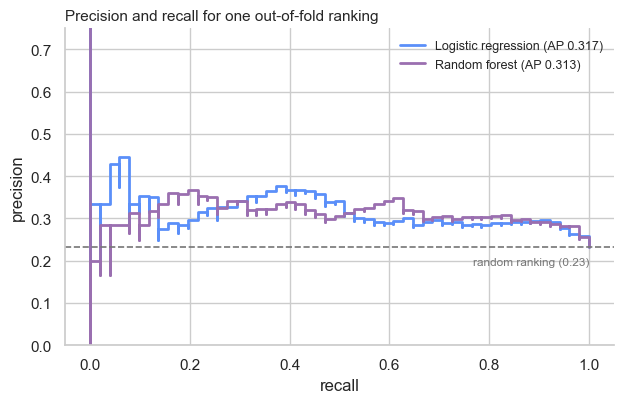

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

for name, scores in oof_scores.items():
    precision, recall, _ = precision_recall_curve(y, scores)
    ax.step(recall, precision, where="post", linewidth=2,
            color=MODEL_COLOURS[name],
            label=f"{name} (AP {average_precision_score(y, scores):.3f})")

ax.axhline(PREVALENCE, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.text(1.0, PREVALENCE - 0.025, f"random ranking ({PREVALENCE:.2f})",
        fontsize=8.5, color=REFERENCE, va="top", ha="right")

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision and recall for one out-of-fold ranking", loc="left",
             fontsize=11)
ax.set_ylim(0, 0.75)
ax.legend(frameon=False, fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig("../figures/09_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
def precision_at_k(y_true, scores, k):
    top = np.argsort(-scores)[:k]
    hits = int(y_true.iloc[top].sum())
    return hits / k, hits / y_true.sum(), hits


rows = []
for name, scores in oof_scores.items():
    for k in [10, 20, 30, 50]:
        prec, rec, hits = precision_at_k(y, scores, k)
        rows.append({"model": name, "k": k, "precision@k": round(prec, 3),
                     "recall@k": round(rec, 3), "found": f"{hits}/{k}"})

at_k = pd.DataFrame(rows).pivot(index="k", columns="model",
                                values=["precision@k", "found"])
print(f"the positive rate in the whole dataset is {PREVALENCE:.1%}\n")
at_k

the positive rate in the whole dataset is 23.3%



precision@k                             found              
model Logistic regression Random forest Logistic regression Random forest
k                                                                        
10                    0.4           0.2                4/10          2/10
20                   0.35          0.25                7/20          5/20
30                  0.267         0.367                8/30         11/30
50                   0.34          0.32               17/50         16/50

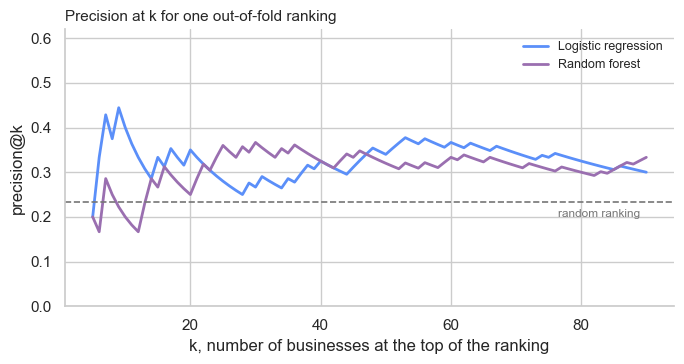

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.8))

k_grid = np.arange(5, 91)
for name, scores in oof_scores.items():
    curve = [precision_at_k(y, scores, k)[0] for k in k_grid]
    ax.plot(k_grid, curve, linewidth=2, color=MODEL_COLOURS[name], label=name)

ax.axhline(PREVALENCE, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.text(89, PREVALENCE - 0.015, "random ranking", fontsize=8.5,
        color=REFERENCE, ha="right", va="top")

ax.set_xlabel("k, number of businesses at the top of the ranking")
ax.set_ylabel("precision@k")
ax.set_title("Precision at k for one out-of-fold ranking", loc="left",
             fontsize=11)
ax.set_ylim(0, 0.62)
ax.legend(frameon=False, fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig("../figures/10_precision_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

### Ranking results

In this one ranking, logistic regression has 4 of the top 10 and 7 of the top 20,
and the random forest has 2 of the top 10 and 11 of the top 30. Both models are
above the 23.3% positive rate at most values of k, but not at every value, and the
two models put different businesses at the top.

At small k the curve jumps around, which is partly arithmetic: with k = 10, one
business is 10 percentage points. The curve is smoother at larger k. I do not want
to read a recommended cutoff out of this, because it comes from one 5-fold split
of 219 rows. Choosing a cutoff would need repeated splits, and it also depends on
how many businesses the coordinator can actually contact, which I still need to
ask about.

## 7. Which features the models use

The logistic coefficients show the direction of each category, while permutation
importance measures how much the ranking changes when a column is shuffled.

For the coefficients I fit on all 219 rows, so this describes the pattern in the
dataset rather than out-of-sample behaviour.

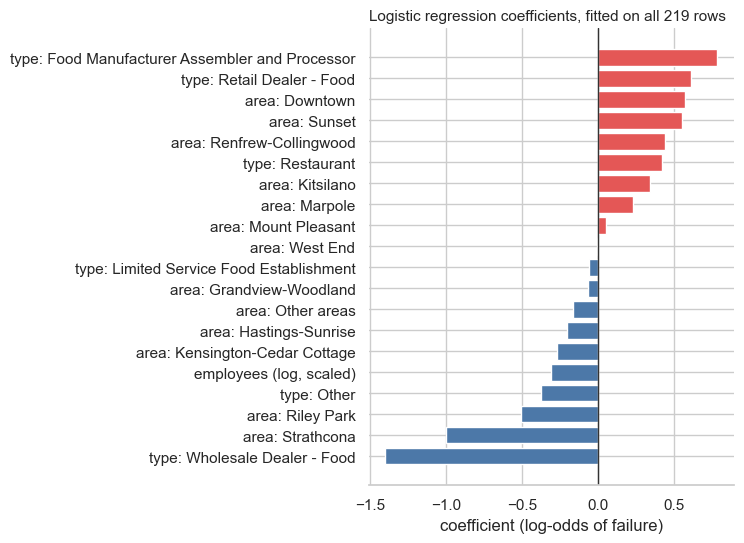

In [12]:
def tidy_name(name):
    name = name.split("__")[-1]
    for prefix, short in [("businesstype_grouped_", "type: "),
                          ("localarea_grouped_", "area: ")]:
        if name.startswith(prefix):
            return short + name[len(prefix):]
    return "employees (log, scaled)" if name == "numberofemployees" else name


logit = clone(MODELS["Logistic regression"]).fit(X, y)
coefs = (pd.Series(logit.named_steps["clf"].coef_[0],
                   index=logit.named_steps["pre"].get_feature_names_out())
           .rename(tidy_name)
           .sort_values())

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.barh(coefs.index, coefs.values,
        color=[PALETTE["failed"] if v > 0 else PALETTE["survived"] for v in coefs])
ax.axvline(0, color="#333333", linewidth=1)

ax.set_xlabel("coefficient (log-odds of failure)")
ax.set_title("Logistic regression coefficients, fitted on all 219 rows",
             loc="left", fontsize=11)
sns.despine(left=True)
fig.tight_layout()
fig.savefig("../figures/11_logistic_coefficients.png", dpi=150,
            bbox_inches="tight")
plt.show()

On a small dataset, calculating permutation importance on the same rows used to fit
the forest can be misleading because part of the result measures how much the model
memorised those rows. I therefore calculate it inside cross-validation by fitting a
fresh copy of the pipeline on each training fold,
then permute the columns of the held-out fold and measure the drop in AP there.
The numbers below are the mean over the five validation folds, and the error bars
are the standard deviation across those folds.

In [13]:
importance_folds = []
for train_idx, valid_idx in StratifiedKFold(
        n_splits=5, shuffle=True, random_state=SEED).split(X, y):
    fold_model = clone(MODELS["Random forest"])
    fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

    result = permutation_importance(
        fold_model, X.iloc[valid_idx], y.iloc[valid_idx],
        scoring="average_precision", n_repeats=20, random_state=SEED)
    importance_folds.append(pd.Series(result.importances_mean, index=X.columns))

importance_df = pd.DataFrame(importance_folds)
importance = importance_df.mean().sort_values()
spread = importance_df.std().loc[importance.index]

summary = pd.DataFrame({"mean drop in AP": importance.round(4),
                        "sd across folds": spread.round(4)})
summary.loc[::-1]

,mean drop in AP,sd across folds
businesstype_grouped,0.0615,0.0452
numberofemployees,0.0181,0.0542
localarea_grouped,-0.0058,0.0626


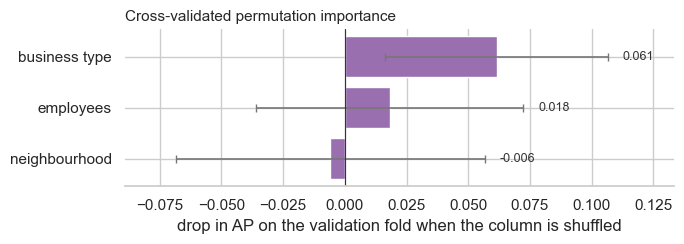

In [14]:
LABELS = {"businesstype_grouped": "business type",
          "localarea_grouped": "neighbourhood",
          "numberofemployees": "employees"}

fig, ax = plt.subplots(figsize=(7, 2.6))
bars = ax.barh([LABELS[i] for i in importance.index], importance.values,
               xerr=spread.values, color=MODEL_COLOURS["Random forest"],
               error_kw={"ecolor": REFERENCE, "elinewidth": 1.2, "capsize": 3})
for bar, value, error in zip(bars, importance.values, spread.values):
    ax.text(value + error + 0.006, bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}", va="center", fontsize=9, color="#333333")

ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("drop in AP on the validation fold when the column is shuffled")
ax.set_title("Cross-validated permutation importance", loc="left", fontsize=11)
ax.set_xlim(min(0, (importance.values - spread.values).min() * 1.3),
            (importance.values + spread.values).max() * 1.25)
sns.despine(left=True)
fig.tight_layout()
fig.savefig("../figures/12_permutation_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()

### Feature results

The coefficients point the same way as the failure rates in the EDA.
`Wholesale Dealer - Food` has the most negative coefficient and Strathcona is the
most negative neighbourhood, while food manufacturers, food retailers and Downtown
are on the positive side. More employees lowers the predicted risk slightly.

The cross-validated permutation importances are small and vary across folds.
Business type has the largest positive mean drop, at about 0.06. Employee count is
close to zero (0.018), and neighbourhood comes out
slightly negative (-0.006), which means that in these five folds shuffling it made
the ranking very slightly better on average. A negative value here does not mean
the column is harmful; it usually means the column is not contributing much and
the measurement is noisy. The fold-to-fold standard deviations are large relative
to the mean values, especially for employee count and neighbourhood.

Given this variation, I cannot confidently rank the three predictors. Business type
looks like the most useful one, which matches the EDA, but I would not claim anything
firm about the other two from five folds and 51 positives.

Since there are only three predictors, it is possible that the limited feature set
is restricting how well these models can do. I have not tested that, so it is a
possibility and not a conclusion.

## 8. Draft diagnostic ranking

The table below shows the top of the out-of-fold ranking as a diagnostic for checking
the model. It is not a contact list because:

1. Every business here already has a known status, so a business that is already
   `Cancelled` does not need a support call.
2. The scores come from five different fold models pooled together. A real list
   would come from one selected model, fitted once, and applied to current
   businesses.

I show the logistic regression ranking because it was slightly better at small k
in this split and because coefficients are easier to explain. That is not a final
model choice.

In [15]:
ranked = model_df.copy()
ranked["risk_score"] = oof_scores["Logistic regression"]
ranked["rank"] = ranked["risk_score"].rank(ascending=False,
                                           method="first").astype(int)
ranked = ranked.sort_values("rank")

top15 = ranked.head(15)[["rank", "licencenumber", "businessname",
                         "businesstype_grouped", "localarea_grouped",
                         "numberofemployees", "risk_score", "status"]]
print(f"failure statuses in this top 15: "
      f"{int(top15['status'].isin(WIDE_STATUSES).sum())}")
top15.round({"risk_score": 3}).set_index("rank")

failure statuses in this top 15: 5


,licencenumber,businessname,businesstype_grouped,localarea_grouped,numberofemployees,risk_score,status
rank,,,,,,,
1,24-259029,(Sharleen Khurana),Retail Dealer - Food,Sunset,1.0,0.854,Issued
2,24-243829,1158456 B.C. LTD.,Retail Dealer - Food,Sunset,2.0,0.842,Issued
3,24-288243,1292761 B.C. LTD.,Food Manufacturer Assembler and Processor,Downtown,2.0,0.806,Pending
4,24-130232,The Nut Merchant Ltd,Food Manufacturer Assembler and Processor,Sunset,2.0,0.796,Issued
5,24-277801,Moltaqa Restaurant Corp,Restaurant,Downtown,1.0,0.785,Issued
6,24-275775,1499323 BC LTD.,Retail Dealer - Food,Sunset,0.0,0.783,Cancelled
7,24-274206,The Hestia Veggie Ltd,Restaurant,West End,0.0,0.776,Cancelled
8,24-267018,1485877 BC Ltd,Retail Dealer - Food,Downtown,4.0,0.773,Issued
9,24-262159,1459640 B.C. LTD.,Retail Dealer - Food,Downtown,2.0,0.768,Cancelled


In [16]:
placement = (ranked.groupby("status")
                   .agg(n=("rank", "size"),
                        median_rank=("rank", "median"),
                        median_score=("risk_score", "median"))
                   .sort_values("median_rank")
                   .round(3))
placement

,n,median_rank,median_score
status,,,
Cancelled,18,52.0,0.649
Pending,26,81.0,0.564
Gone Out of Business,2,112.5,0.466
Issued,168,117.5,0.462
Inactive,5,121.0,0.449


### Status results

In the ranking of 219 businesses, where the middle is around rank 110, `Cancelled`
businesses have a median rank of 52 and `Pending` businesses have a median rank of
81. `Gone Out of Business` and
`Inactive` sit near or below the middle, so in this ranking they are not being
picked up.

After cleaning there are only 2 `Gone Out of Business` records and 5 `Inactive`
records, and this is one out-of-fold ranking. Those
groups are far too small to conclude that the model cannot detect them. What I can
say is that the four statuses in the wide label do not appear to behave the same
way in this sample, and that the wide label is combining groups that may not
belong together. Checking this properly is part of the label sensitivity work in
Section 9.

## 9. Draft summary and what is left

### Where the draft stands

- Both models score above the AP of a random ranking, 0.375 and 0.385 against
  0.233. The predictors carry some signal.
- The two averages are similar and I cannot say from this analysis that one model
  is better than the other.
- Precision@k in the one out-of-fold ranking is above the base rate at most values
  of k, but it moves around a lot at small k, and I am not choosing a cutoff from
  it yet.
- In the cross-validated permutation importance, business type has the largest
  positive mean, and all three results vary noticeably across folds.
- The failure statuses do not sit in the same part of the ranking, though the
  smaller status groups have too few records to say much.
- The models have not been tuned, so these are still draft results.

### Limitations

The dataset is 219 rows with 51 positives, so every number here carries a lot of
uncertainty. The label definition is not settled. The category grouping thresholds
were chosen on the full dataset before splitting. The ranking analysis rests on a
single 5-fold split. The model is also cross-sectional, so it is learning which
kinds of businesses currently have failure statuses, not what happens to a
business over time.

### To do before the final delivery on August 11

- [ ] Label sensitivity: rerun with `Pending` excluded, with the narrow label, and
      with a `Cancelled`-only label, and compare
- [ ] Hyperparameter tuning for both models, nested inside the cross-validation so
      the reported scores stay honest
- [ ] Repeat the ranking analysis over several splits instead of one, then look at
      a cutoff
- [ ] One held-out evaluation at the end as a final check
- [ ] Check whether the predicted probabilities are calibrated or should only be
      used as ranks
- [ ] Choose a final model and write down the reason
- [ ] Build the actual contact list from one fitted model, with businesses that
      are already closed removed
- [ ] Short plain-language summary for the client

### Questions I still need to ask the client

1. Should `Pending` count as a failed business? Section 8 gives some reason to
   look at `Pending` and `Inactive` separately from `Cancelled`, but not enough to
   decide it myself.
2. How was the 63% baseline in the Phase 2 agreement calculated? A majority-class
   model gets 76.7% accuracy here while finding no failures, so I want to know
   what the 63% was measuring.
3. How many businesses can the coordinator contact in a week? That number affects
   where a cutoff on the ranked list would go.